# **Stock Prediction using SUPPORT VECTOR REGRESSION**

### *Importing Libraries*

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### *Load Dataset from Local directory*

In [48]:
# Download CSV from: https://github.com/msabid/stock_data/blob/main/aapl_ticker.csv
df = pd.read_csv("aapl_ticker.csv")
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [49]:
# Keep recent 250 days
df = df.tail(250).copy()

# *Create day index*

In [50]:
df['Day_Index'] = np.arange(len(df))

# *Feature Engineering*

In [51]:
df['Prev_Close'] = df['Close'].shift(1)         # Previous day's close
df['MA5'] = df['Close'].rolling(5).mean()      # 5-day moving average
df = df.dropna()

# *Feature and target*

In [52]:
# Features: Day index + Prev_Close + MA5 + High + Low + Volume
X = df[['Day_Index', 'Prev_Close', 'MA5', 'High', 'Low', 'Volume']].values
y = df['Close'].values

# *Feature scaling*

In [53]:
sc_X = StandardScaler()
sc_y = StandardScaler()
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1,1))

# *train-test split*

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

### *Train SVR model*

In [55]:
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.01)
svr_model.fit(X_train, y_train.ravel())

SVR(C=100, epsilon=0.01, gamma=0.1)

## 🌟 Predict on Test Set

In [56]:
y_pred_scaled = svr_model.predict(X_test)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))
y_test_actual = sc_y.inverse_transform(y_test.reshape(-1,1))

# *Evaluate Model*

In [57]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)
print(f"Root Mean Square Error: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Root Mean Square Error: 3.61
R2 Score: 0.68


### *Prediction for all test data for validation*
### *SSres is the sum of squares of the residual errors.*
### *SStot is the total sum of the errors.*
# 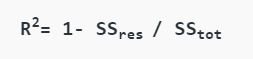

# *user input prediction*

In [58]:
# User input prediction (Step 11)
day_input = int(input(f"Enter future day index (>= {len(df)}): "))
prev_close = df['Close'].iloc[-1]
ma5 = df['Close'].tail(5).mean()
high = df['High'].iloc[-1]    # last high
low = df['Low'].iloc[-1]      # last low
volume = df['Volume'].iloc[-1] # last volume

user_features = np.array([[day_input, prev_close, ma5, high, low, volume]])
user_scaled = sc_X.transform(user_features)
pred_scaled = svr_model.predict(user_scaled)
pred_price = sc_y.inverse_transform(pred_scaled.reshape(-1,1))
print(f"Predicted Stock Price on day {day_input}: ${pred_price[0][0]:.2f}")

Enter future day index (>= 246): 100
Predicted Stock Price on day 100: $172.45


# *visualization*

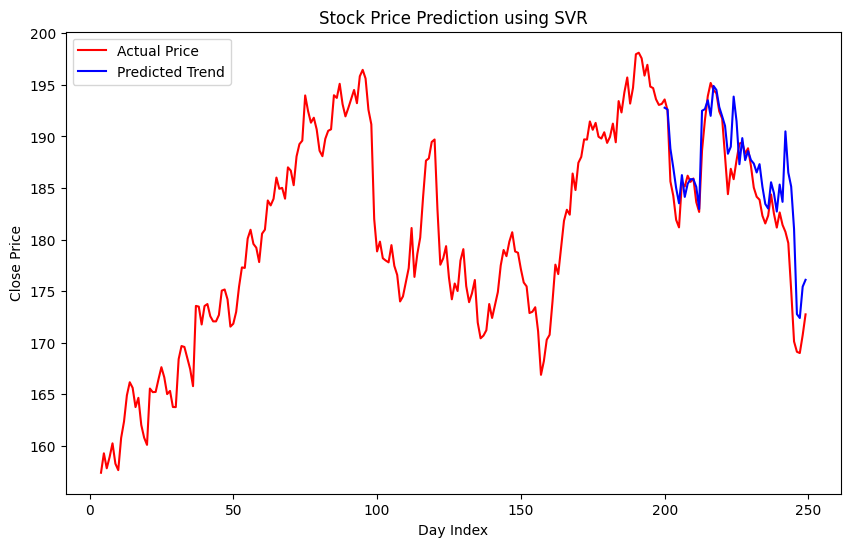

In [59]:
plt.figure(figsize=(10,6))
plt.plot(df['Day_Index'], df['Close'], color='red', label='Actual Price')
plt.plot(df['Day_Index'].iloc[-len(y_test):], y_pred, color='blue', label='Predicted Trend')
plt.title("Stock Price Prediction using SVR")
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend()
plt.show()